In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split


In [3]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error
)

In [4]:
# Load processed dataset
df = pd.read_csv("../datasets/preprocessed_data.csv")


In [5]:
X = df.drop(columns=["US_AQI"])
y = df["US_AQI"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
modelX = joblib.load("../trained_models/xgboost.pkl")

In [8]:
y_predX = modelX.predict(X_test)

In [9]:
# Evaluation metrics
mae = mean_absolute_error(y_test, y_predX)
mse = mean_squared_error(y_test, y_predX)
rmse = root_mean_squared_error(y_test, y_predX)
r2 = r2_score(y_test, y_predX)

print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

MAE  : 12.07
R²   : 0.8825
MSE  : 590.5283
RMSE : 24.3008


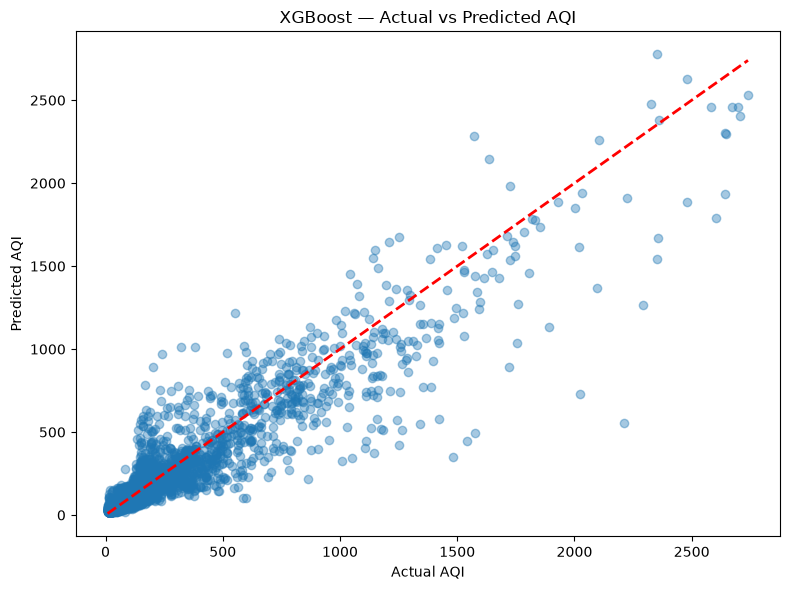

In [10]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_predX,
    alpha=0.4
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("XGBoost — Actual vs Predicted AQI")

plt.tight_layout()
plt.show()

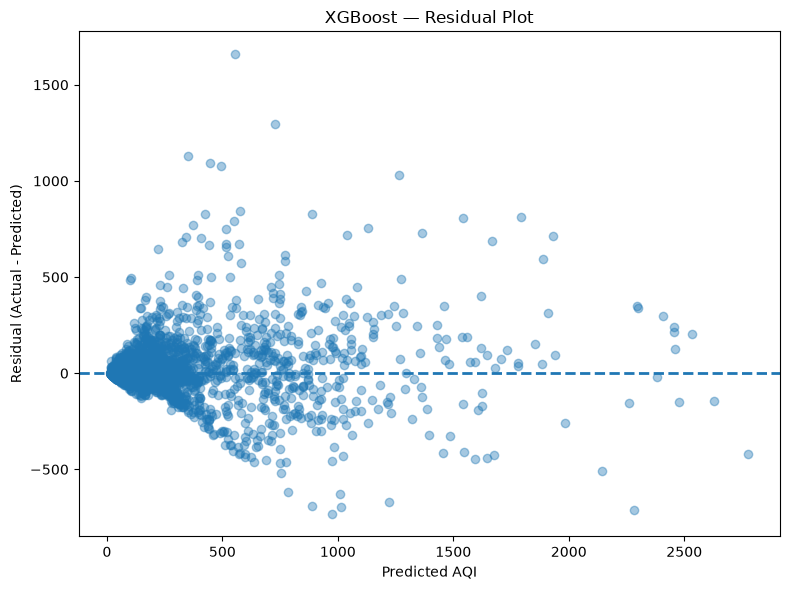

In [11]:
import numpy as np
import matplotlib.pyplot as plt

residuals = y_test - y_predX

plt.figure(figsize=(8, 6))

plt.scatter(
    y_predX,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted AQI")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("XGBoost — Residual Plot")

plt.tight_layout()
plt.show()

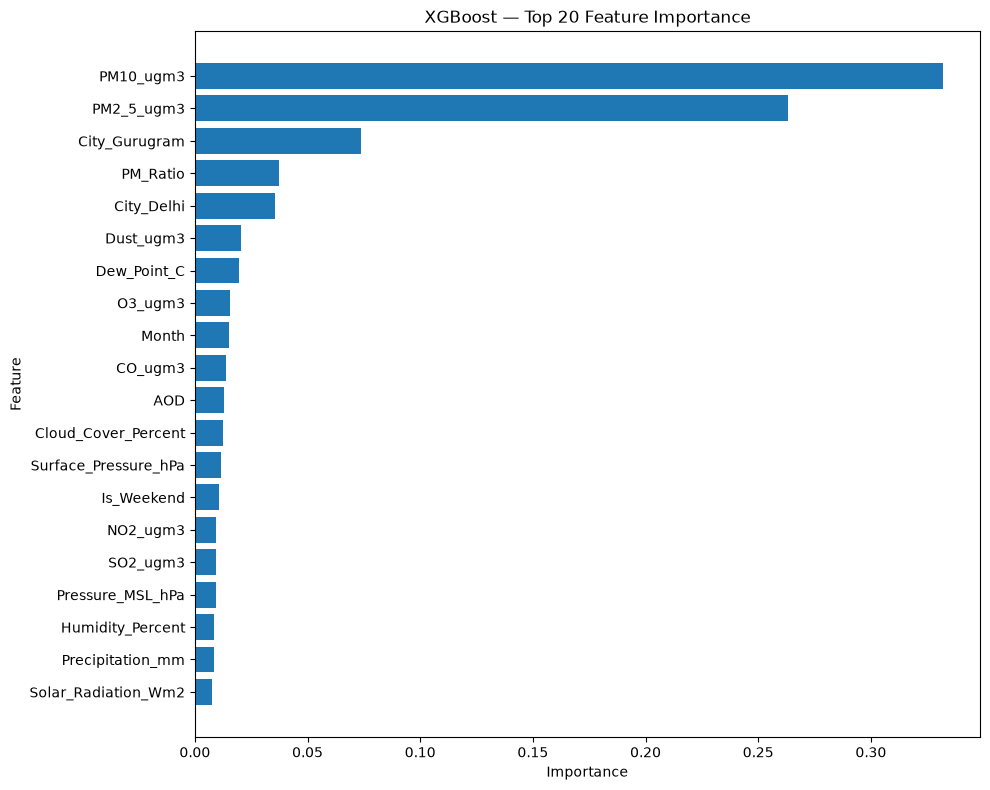

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": modelX.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

# Top 20 features
top20 = importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost — Top 20 Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

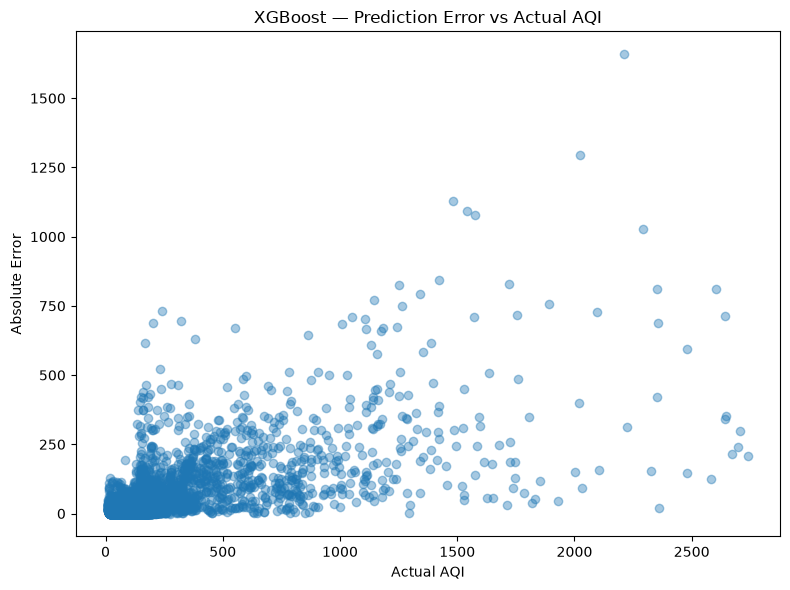

In [13]:
import numpy as np
import matplotlib.pyplot as plt

absolute_error = np.abs(y_test - y_predX)

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    absolute_error,
    alpha=0.4
)

plt.xlabel("Actual AQI")
plt.ylabel("Absolute Error")
plt.title("XGBoost — Prediction Error vs Actual AQI")

plt.tight_layout()
plt.show()

Random Forest

In [14]:
modelR = joblib.load("../trained_models/random_forest.pkl")

print("Random Forest loaded successfully!")

Random Forest loaded successfully!


In [15]:
y_predR = modelR.predict(X_test)

print("Predictions generated!")
print("Number of predictions:", len(y_predR))

Predictions generated!
Number of predictions: 168403


In [16]:
mae_R = mean_absolute_error(y_test, y_predR)
mse_R = mean_squared_error(y_test, y_predR)
rmse_R = root_mean_squared_error(y_test, y_predR)
r2_R = r2_score(y_test, y_predR)

print(f"MAE  : {mae_R:.2f}")
print(f"R²   : {r2_R:.4f}")
print(f"MSE  : {mse_R:.4f}")
print(f"RMSE : {rmse_R:.4f}")

MAE  : 9.90
R²   : 0.8926
MSE  : 539.7745
RMSE : 23.2330


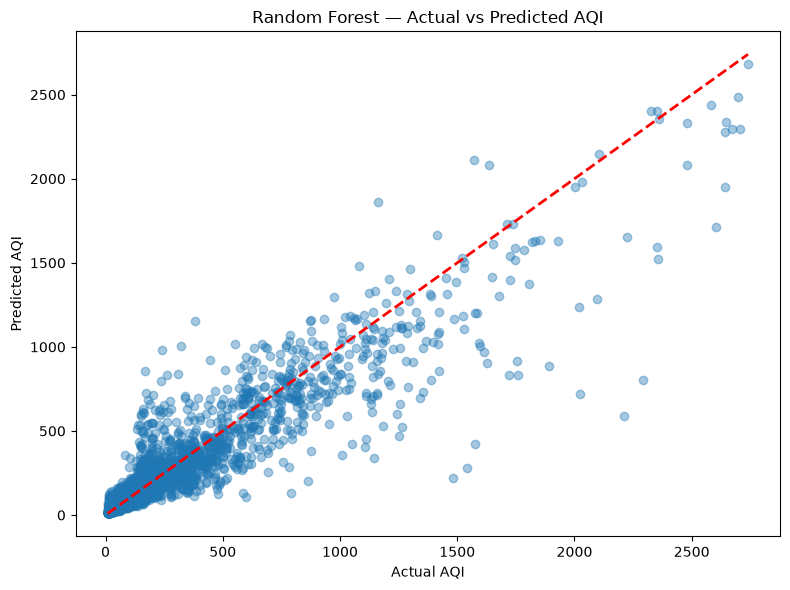

In [17]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_predR,
    alpha=0.4
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Random Forest — Actual vs Predicted AQI")

plt.tight_layout()
plt.show()

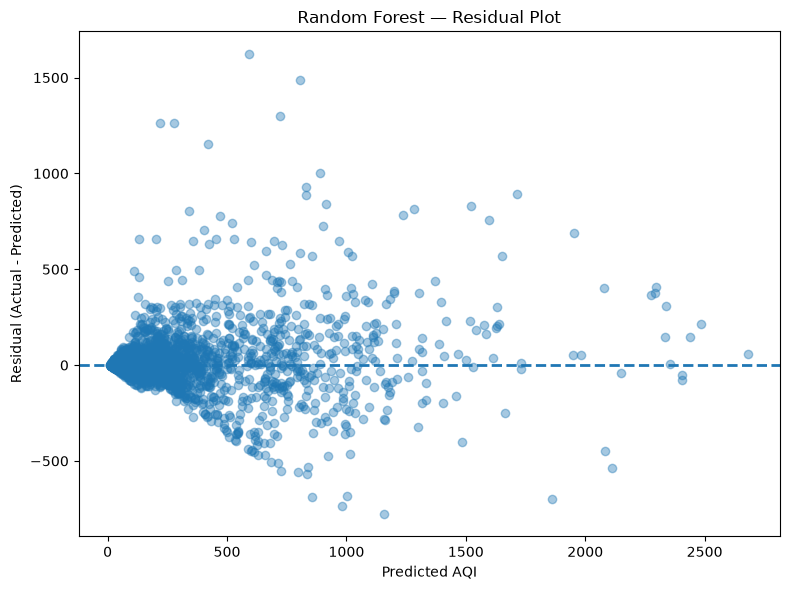

In [18]:
residuals_R = y_test - y_predR

plt.figure(figsize=(8, 6))

plt.scatter(
    y_predR,
    residuals_R,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted AQI")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Random Forest — Residual Plot")

plt.tight_layout()
plt.show()

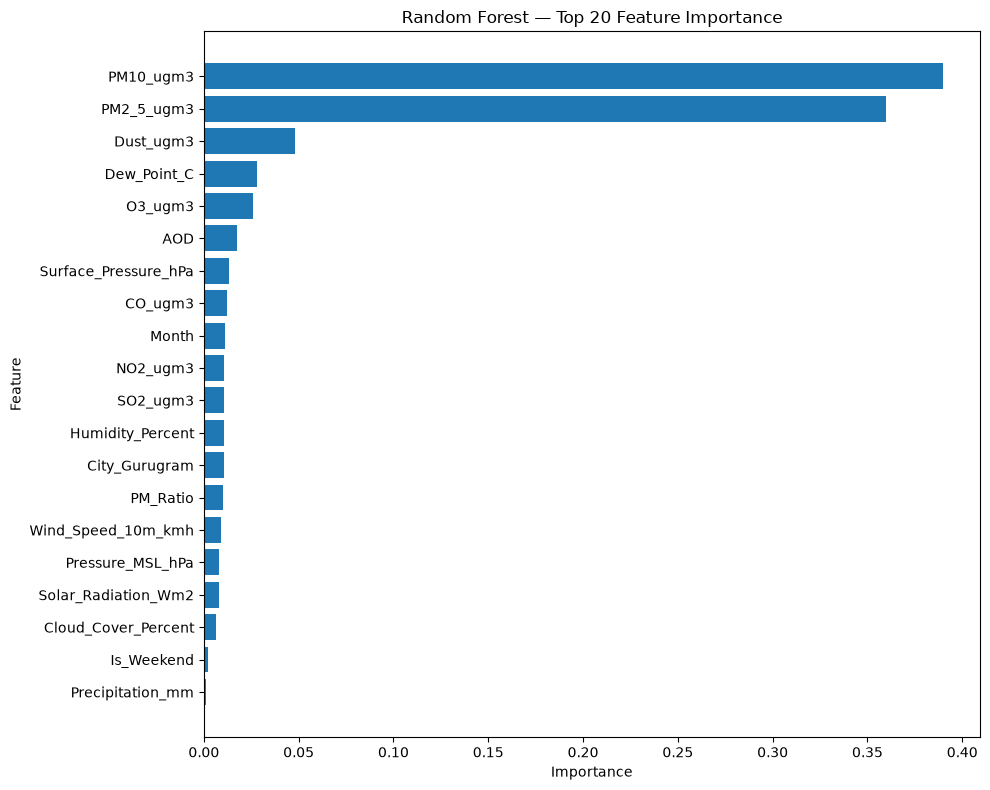

In [19]:
import pandas as pd

importance_R = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": modelR.feature_importances_
})

importance_R = importance_R.sort_values(
    by="Importance",
    ascending=False
)

top20_R = importance_R.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top20_R["Feature"],
    top20_R["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest — Top 20 Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


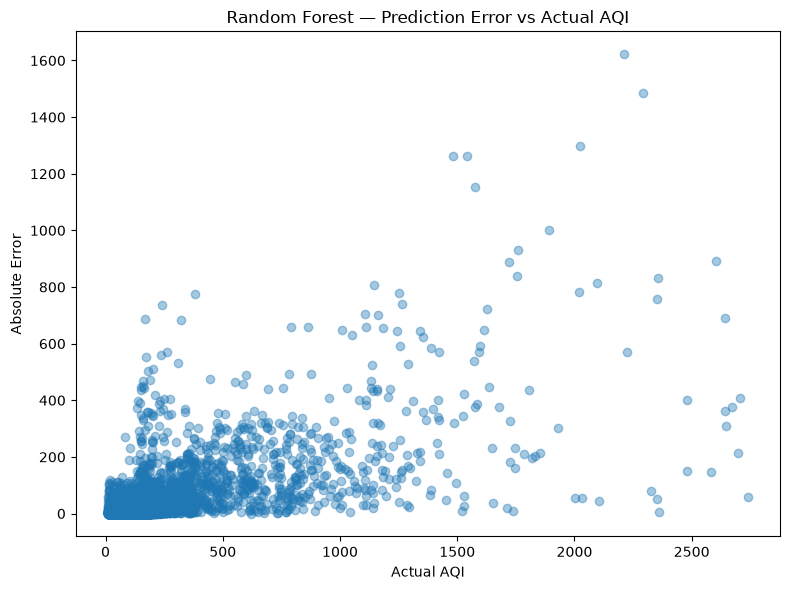

In [20]:
import numpy as np

absolute_error_R = np.abs(y_test - y_predR)

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    absolute_error_R,
    alpha=0.4
)

plt.xlabel("Actual AQI")
plt.ylabel("Absolute Error")
plt.title("Random Forest — Prediction Error vs Actual AQI")

plt.tight_layout()
plt.show()

In [21]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MAE": [
        mean_absolute_error(y_test, y_predR),
        mean_absolute_error(y_test, y_predX)
    ],
    "RMSE": [
        root_mean_squared_error(y_test, y_predR),
        root_mean_squared_error(y_test, y_predX)
    ],
    "R²": [
        r2_score(y_test, y_predR),
        r2_score(y_test, y_predX)
    ],
    "MSE": [
        mean_squared_error(y_test, y_predR),
        mean_squared_error(y_test, y_predX)
    ]
})

comparison

,Model,MAE,RMSE,R²,MSE
0,Random Forest,9.899365,23.233049,0.892593,539.774548
1,XGBoost,12.069243,24.300788,0.882494,590.528291
